In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import seaborn as sns
import math
#from plotnine import *
#import scvi
import os
import pickle

import seaborn as sns
#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(5,5))
%matplotlib inline
sc.settings.verbosity = 0


In [2]:
DATA_PREPARED=True

In [3]:
if DATA_PREPARED:
    adata_iii=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_eczema_scrna.h5ad")
else:
    adata=sc.read_h5ad("/nfs/team361/ls34/inflow/final_adatas/adata_all_scrna.h5ad")






In [4]:
if not DATA_PREPARED: 
    adata.obs["Site_status_binary"]=adata.obs["Site_status_simple"]
    adata_i=adata[adata.obs["Patient_status"]=="Eczema"]
    adata_i.obs["Site_status_binary"].value_counts()
    mapping_dict = {'SKN8090524': ['E2'],
     'SKN8090525': ['E2'],
     'SKN8090526': ['E2'],
     'SKN8090527': ['E2'],
     'SKN8090528': ['E2'],
     'SKN8090529': ['E2'],
     'SKN8090530': ['E2'],
     'SKN8090531': ['E2'],
     'SKN8090536': ['E3'],
     'SKN8090537': ['E3'],
     'SKN8090538': ['E3'],
     'SKN8090539': ['E3'],
     'SKN8090540': ['E3'],
     'SKN8090541': ['E3'],
     'SKN8090542': ['E3'],
     'SKN8090543': ['E3'],
     'SKN8090548': ['E4'],
     'SKN8090549': ['E4'],
     'SKN8090550': ['E4'],
     'SKN8090551': ['E4'],
     'SKN8090552': ['E4'],
     'SKN8090553': ['E4'],
     'SKN8090554': ['E4'],
     'SKN8090555': ['E4'],
     'SKN8090560': ['E1'],
     'SKN8090561': ['E1'],
     'SKN8090562': ['E1'],
     'SKN8090563': ['E1'],
     'SKN8090564': ['E1'],
     'SKN8090565': ['E1'],
     'SKN8090566': ['E1'],
     'SKN8090567': ['E1'],
     'SKN8090576': ['P1'],
     'SKN8090577': ['P1'],
     'SKN8090578': ['P1'],
     'SKN8090579': ['P1'],
     'SKN8090580': ['P1'],
     'SKN8090581': ['P1'],
     'SKN8090582': ['P1'],
     'SKN8090583': ['P1'],
     'SKN8090588': ['P2'],
     'SKN8090589': ['P2'],
     'SKN8090590': ['P2'],
     'SKN8090591': ['P2'],
     'SKN8090592': ['P2'],
     'SKN8090593': ['P2'],
     'SKN8090594': ['P2'],
     'SKN8090595': ['P2'],
     'SKN8090600': ['P3'],
     'SKN8090601': ['P3'],
     'SKN8090602': ['P3'],
     'SKN8090603': ['P3'],
     'SKN8090604': ['P3'],
     'SKN8090605': ['P3'],
     'SKN8090606': ['P3'],
     'SKN8090607': ['P3'],
     'SKN8104894': ['S4'],
     'SKN8104895': ['S4'],
     'SKN8104896': ['S4'],
     'SKN8104897': ['S4'],
     'SKN8104899': ['S4'],
     'SKN8104900': ['S4'],
     'SKN8104901': ['S4'],
     'SKN8104902': ['S4'],
     'SKN8105192': ['S5'],
     'SKN8105193': ['S5'],
     'SKN8105194': ['S5'],
     'SKN8105195': ['S5'],
     'SKN8105197': ['S5'],
     'SKN8105198': ['S5'],
     'SKN8105199': ['S5'],
     'SKN8105200': ['S5'],
     '4820STDY7388991': ['s1'],
     '4820STDY7388992': ['s1'],
     '4820STDY7388993': ['s1'],
     '4820STDY7388994': ['s1'],
     '4820STDY7388995': ['s1'],
     '4820STDY7388996': ['s1'],
     '4820STDY7388997': ['s1'],
     '4820STDY7388998': ['s1'],
     '4820STDY7388999': ['s2'],
     '4820STDY7389000': ['s2'],
     '4820STDY7389001': ['s2'],
     '4820STDY7389002': ['s2'],
     '4820STDY7389003': ['s2'],
     '4820STDY7389004': ['s2'],
     '4820STDY7389005': ['s2'],
     '4820STDY7389006': ['s2'],
     '4820STDY7389007': ['s3'],
     '4820STDY7389008': ['s3'],
     '4820STDY7389009': ['s3'],
     '4820STDY7389010': ['s3'],
     '4820STDY7389011': ['s3'],
     '4820STDY7389012': ['s3'],
     '4820STDY7389013': ['s3'],

     '4820STDY7389014': ['s3']}
    adata_i.obs["DonorID"] = (
        adata_i.obs["sample_id"]
        .map(lambda x: mapping_dict.get(x, [x])[0])
    )
    print(adata_i.obs["DonorID"].value_counts())
    print(adata_i[adata_i.obs["DonorID"]=="E1"].obs.Site_status_simple.value_counts())
    RENAME = {'E2': 'E2',
     'E3': 'E3',
     'E4': 'E4',
     'E1': 'E1',
     'GSM6595214': 'GSM6595214',
     'GSM6595212': 'GSM6595212',
     'GSM6595211': 'GSM6595211',
     'GSM6595213': 'GSM6595213',
     'GSM6595210': 'GSM6595210',
     'AD10': 'AD10',
     'AD11': 'AD11',
     'AD12': 'AD12',
     'AD13': 'AD13',
     'AD14': 'AD14',
     'AD15': 'AD15',
     'AD16': 'AD16',
     'AD17': 'AD17',
     'AD18': 'AD18',
     'AD19': 'AD19',
     'AD1': 'AD1',
     'AD2': 'AD2',
     'AD3': 'AD3',
     'AD4': 'AD4',
     'AD5': 'AD5',
     'AD6': 'AD6',
     'AD7': 'AD7',
     'AD8': 'AD8',
     'BCH01-L1': 'BCH01',
     'BCH01-NL1': 'BCH01',
     'BCH01-NL2': 'BCH01',
     'BCH01-L2': 'BCH01',
     'BCH04-NL2': 'BCH04',
     'BCH04-NL1': 'BCH04',
     'BCH04-L1': 'BCH04',
     'BCH04-L2': 'BCH04',
     'BCH05-NL': 'BCH05',
     'BCH05-L': 'BCH05',
     'BCH06-NL': 'BCH06',
     'BCH06-L': 'BCH06',
     'BCH07-NL': 'BCH07',
     'BCH07-L': 'BCH07',
     'MGH103-NL1': 'MGH103',
     'MGH103-L2': 'MGH103',
     'MGH103-L1': 'MGH103',
     'MGH103-NL2': 'MGH103',
     'MGH104-L1': 'MGH104',
     'MGH104-L2': 'MGH104',
     'MGH104-NL1': 'MGH104',
     'MGH105-L1': 'MGH105',
     'MGH106-L1': 'MGH106',
     'MGH106-L2': 'MGH106',
     'MGH106-NL1': 'MGH106',
     'MGH106-NL2': 'MGH106',
     'MGH108-L1': 'MGH108',
     'MGH108-L2': 'MGH108',
     'MGH108-NL1': 'MGH108',
     'MGH108-NL2': 'MGH108',
     'MGH110-NL': 'MGH110',
     'MGH110-L': 'MGH110'}
    adata_i.obs["DonorID"]=adata_i.obs["DonorID"].map(RENAME).fillna(adata_i.obs["DonorID"])
    print(adata_i[adata_i.obs["DonorID"]=="E1"].obs.Site_status_simple.value_counts())

In [5]:
if not DATA_PREPARED:
    adata_ii = adata_i[~adata_i.obs["DonorID"].str.startswith("GSM")]
    adata_ii = adata_ii[~adata_ii.obs["DonorID"].str.startswith("AD")]
    adata_ii.obs["validation"] = adata_ii.obs["DonorID"].astype(str)  + "_" + adata_ii.obs["Site_status_binary"].astype(str) 
    adata_ii.obs["validation2"] = adata_ii.obs["Site_status_binary"].astype(str)  + "_" +  adata_ii.obs["DonorID"].astype(str) 
        # # ### NORMALISE
    #adata_ii.layers["counts"]=adata_ii.X.copy()
    # adata.layers["counts"]=adata.X.copy()
    sc.pp.normalize_total(adata_ii, target_sum=1e4)
    sc.pp.log1p(adata_ii)
    adata_iii=adata_ii[adata_ii.obs["dataset_id"]=="Reynolds"]
    adata_ii.write("/nfs/team361/ls34/inflow/final_adatas/adata_eczema_scrna.h5ad")
    import gc
    gc.collect()

In [6]:
with open('eczema_tdc_mcp_top200.pkl', 'rb') as f:
    gene_programme200 = pickle.load(f)




# reynolds

In [7]:
# adata_iii=adata_ii[adata_ii.obs["dataset_id"]=="Reynolds"]

In [8]:
adata_iii[adata_iii.obs["DonorID"]=="E1"].obs.Site_status.value_counts()

Site_status
Nonlesional    2794
Lesional       2577
Name: count, dtype: int64

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


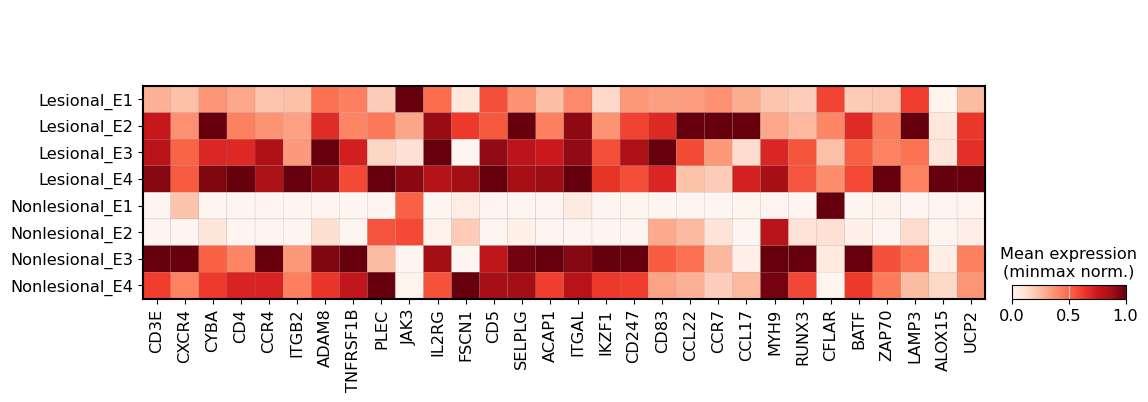

In [15]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds",
                categories_order=sorted(list(adata_iii.obs["validation2"].unique())),
                 colorbar_title="Mean expression\n(minmax norm.)"
                )
# sc.pl.dotplot(adata_iii, 
#               gene_programme200[:30],
#               groupby="validation2",
#               dendrogram=True, 
#                 standard_scale="var",
#                 cmap="Reds")

In [ ]:
stop

In [10]:
sorted(list(adata_iii.obs["validation2"].unique()))

['Lesional_E1',
 'Lesional_E2',
 'Lesional_E3',
 'Lesional_E4',
 'Nonlesional_E1',
 'Nonlesional_E2',
 'Nonlesional_E3',
 'Nonlesional_E4']

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


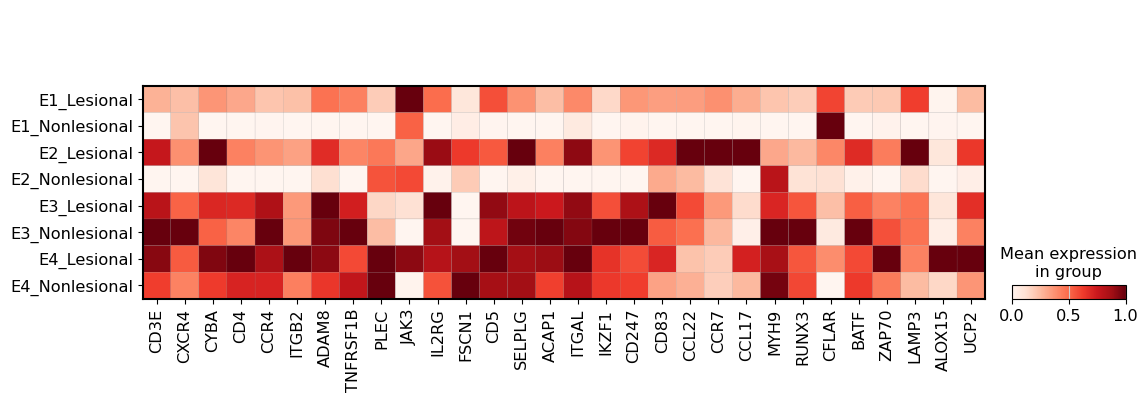

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

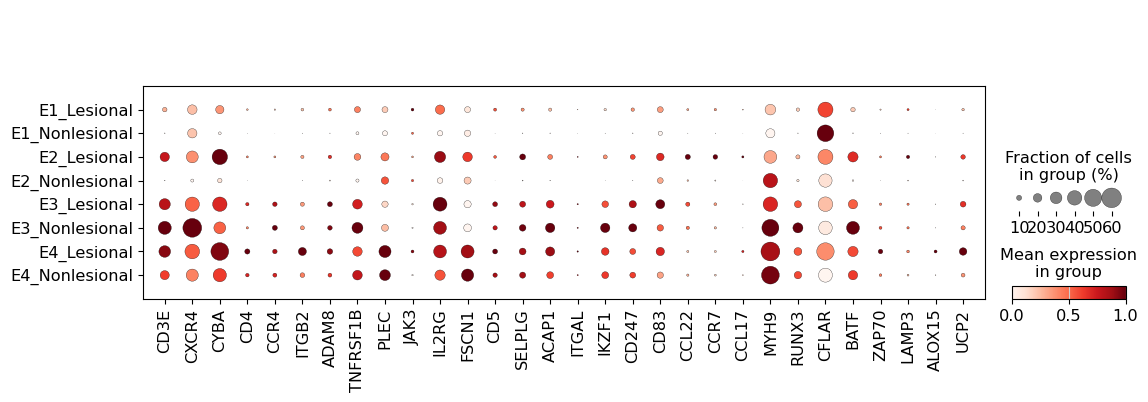

In [11]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


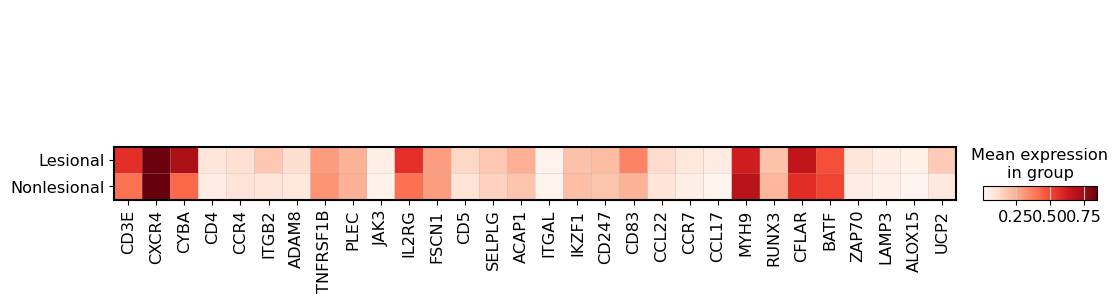

/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/jovyan/my-conda-envs/sko_ls/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

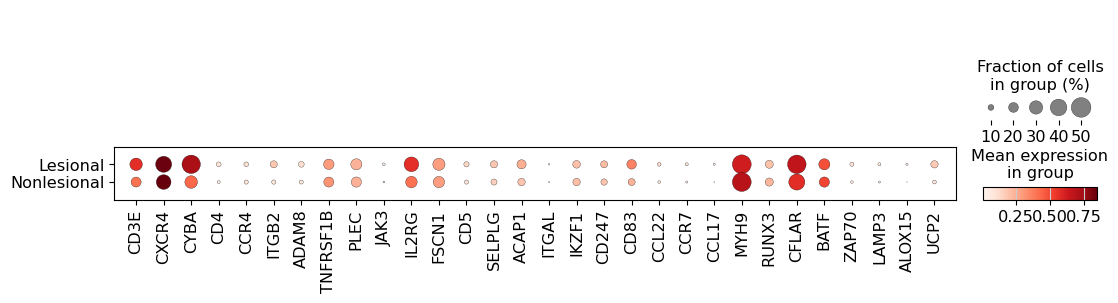

In [12]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="Site_status",
              dendrogram=False, 
                #standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="Site_status",
              dendrogram=False, 
              #  standard_scale="var",
                cmap="Reds")

In [13]:
adata_iii.obs["validation"].value_counts()

validation
E4_Lesional       23682
E4_Nonlesional    15334
E3_Lesional       13305
E3_Nonlesional     8408
E2_Lesional        5524
E2_Nonlesional     4301
E1_Nonlesional     2794
E1_Lesional        2577
Name: count, dtype: int64

In [14]:
CONTROL_SIZE = 1000 #
N_BINS=25  
ADATA = adata_ii
adata_ii = sc.tl.score_genes(adata_ii, gene_programme200[:50], ctrl_size=CONTROL_SIZE, n_bins=N_BINS, copy=True, score_name="TDC_MCP")

cluster_scores = adata_ii.obs.groupby('validation')[['TDC_MCP']].mean()

NameError: name 'adata_ii' is not defined

In [ ]:
def plot_boxplot(cluster_scores_long, FIGSIZE=(12, 6)):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Boxplot with swapped axes (distribution of 'Stroma_MCP' across 'Patient_status2')
    sns.boxplot(
        data=cluster_scores_long,
        x="Site_status",  # Group by 'Patient_status2' on the x-axis
        y="TDC_MCP",       # Distribution of 'Stroma_MCP' score on the y-axis
        ax=ax,
        width=0.6
    )

    # Stripplot (overlay sample-level points) showing dots for each 'sample_id'
    # sns.stripplot(
    #     data=cluster_scores_long,
    #     x="validation",  # Group by 'Patient_status2' on the x-axis
    #     y="TDC_MCP",       # The 'Stroma_MCP' scores on the y-axis
    #     ax=ax,
    #     jitter=True,
    #     color='black',
    #     alpha=0.1,
    #     zorder=3,
    #     size=0.1,  # Adjust size of dots for clarity
    #     #hue="sample_id",  # Each sample will be colored by its 'sample_id'
    #     dodge=True,  # Separates dots by 'sample_id'
    #     legend=False  # Turn off the legend to avoid clutter
    # )

    # Remove background grid
    ax.grid(False)

    # Customizing plot
    ax.set_title("Boxplot of Stroma_MCP by Patient Status (Sample-Level Variation)")
    ax.set_xlabel("Patient Status")
    ax.set_ylabel("Stroma_MCP Score")

    plt.tight_layout()
    plt.show()
    
cluster_scores_long = ADATA.obs[['Site_status', 'validation', 'TDC_MCP']].copy()
    
plot_boxplot(cluster_scores_long)

In [ ]:
0

In [ ]:
stop

# MigDC

In [ ]:
import scanpy as sc
adata=sc.read_h5ad('/nfs/team298/ls34/new_disease_atlas/final_adatas/adata_scrna8.h5ad')
# #adata=adata[adata.obs["tech"]!="xenium"]
# adata

adata





In [ ]:
adata=adata[adata.obs["Patient_status"]=="Eczema"]


In [ ]:
# # ### NORMALISE
#adata_ii.layers["counts"]=adata_ii.X.copy()
# adata.layers["counts"]=adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [ ]:
adata_i = adata[adata.obs["lvl5_annotation"].str.startswith("Mig")]
adata_i.shape

In [ ]:
del(adata)

In [ ]:
import gc
gc.collect()


In [ ]:
adata_i=adata_i.copy()

In [ ]:
sc.pp.normaalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [ ]:
GENES = {"Chemokines": ["CCL17", "CCL22"],
        "Migration/maturation": ["CCR7", "LAMP3", "CD274"],
         "Type 2 immunity-related": ["ALOX15", "MMP12"]
        }
sc.pl.dotplot(
    adata_i[adata_i.obs["dataset_id"]=="Reynolds"],
    GENES,
    groupby="Site_status_simple",
    #standard_scale="var",
    #dendrogram=True,
    vmax=30, cmap="Reds",
    colorbar_title="Mean expression\n(log1p norm)",
    #save = "validation_of_mcp.pdf"
)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute total number of cells per sample
total_counts = adata_i.obs["sample_id"].value_counts()

# Compute counts per status per sample
status_counts = adata_i.obs.groupby(["sample_id", "Site_status_simple"]).size().unstack(fill_value=0)

# Normalize per 100 cells
normalized = (status_counts.T / total_counts * 100).T

# Reshape for plotting
plot_df = normalized.reset_index().melt(id_vars="sample_id", var_name="Site_status_simple", value_name="cells_per_100")

# Bar plot with mean across samples
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=plot_df,
    x="Site_status_simple",
    y="cells_per_100",
    estimator="mean",
    color="#4CAF50",  # green
    edgecolor="black",
    ci=None
)

# Overlay swarmplot for individual samples
sns.swarmplot(
    data=plot_df,
    x="Site_status_simple",
    y="cells_per_100",
    color="black",
    size=5,
    ax=ax
)

plt.ylabel("Cells per 100 total")
plt.xlabel("")
plt.title("Lesional vs Nonlesional (Normalized)")
plt.grid(False)
plt.tight_layout()
plt.show()

# MGH

In [ ]:
adata_iii=adata_ii[adata_ii.obs["DonorID"].str.startswith("MGH")]

In [ ]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")

In [ ]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")

# BGH

In [ ]:
adata_iii=adata_ii[adata_ii.obs["DonorID"].str.startswith("BCH")]

In [ ]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")

In [ ]:
sc.pl.matrixplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")
sc.pl.dotplot(adata_iii, 
              gene_programme200[:30],
              groupby="validation2",
              dendrogram=False, 
                standard_scale="var",
                cmap="Reds")